In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [4]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# 상태 정의
class State(TypedDict):	
    messages: Annotated[list[str], add_messages]

In [5]:
# 그래프 생성
graph_builder = StateGraph(State)

In [6]:
def generate(state: State):
    return {"messages": [model.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

In [7]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

#### 체크포인트

에이전트의 현재 상태를 저장하여 나중에 중단된 시점부터 다시 시작하거나, 특정 시점으로 돌아갈 수 있게 하는 기능

In [ ]:
from langgraph.checkpoint.memory import MemorySaver # 체크포인트 저장소 중 하나
memory = MemorySaver()

config = {"configurable": {"thread_id": "kim1"}} # thread_id별로 여러 대화 스레드의 상태를 독립적으로 관리

graph = graph_builder.compile(checkpointer=memory)

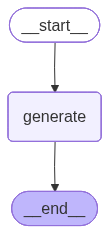

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [13]:
from langchain.schema import HumanMessage

while True:
    user_input = input("You\t:")
    
    if user_input in ["exit", "quit", "q"]:
        break

    for event in graph.stream({
        "messages": [HumanMessage(user_input)]},
        config, # * 추가
        stream_mode="values"
    ):
        event["messages"][-1].pretty_print()

    print(f'\n(현재 메시지 개수: {len(event["messages"])})\n')

================================ Human Message =================================

내 이름은 김일남이야
================================== Ai Message ==================================

안녕하세요, 김일남 님. 만나서 반갑습니다. 무엇을 도와드릴까요?

(현재 메시지 개수: 2)

================================ Human Message =================================

내 이름은?
================================== Ai Message ==================================

당신 이름은 김일남입니다.

(현재 메시지 개수: 4)

================================ Human Message =================================




c:\Users\dandycode\Documents\GitHub\kor-it-langchain-class\ch09\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:1805: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


================================== Ai Message ==================================

(현재 메시지 개수: 6)

